# Decision Tree Regressor

## Import Required Libraries


In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

## Load Engineered Features

In [2]:
df = pd.read_csv('../feature_engineering.csv')

In [3]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

X = df[feature_columns]
y = df['fk_estimated_uk_age_num']

## Model Training and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=456
)

## Hyperparameter Tuning with GridSearchCV

In [5]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R^2:", grid_search.best_score_)
best_tree = grid_search.best_estimator_

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best cross-validated R^2: 0.9828540834791877


## Save the Trained Model

In [6]:
# Save your trained model
joblib.dump(best_tree, '../../models/decision_tree_regressor.joblib')

['../../models/decision_tree_regressor.joblib']

## Evaluate Results

In [7]:
y_pred = best_tree.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print(f"R^2 Score: {r2:.2f}")

y_train_pred = best_tree.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Train MAE: {mae_train:.2f}, Train R^2: {r2_train:.2f}")
print(f"Test MAE: {mae:.2f}, Test R^2: {r2:.2f}")

MAE: 0.33323644954079734
MSE: 0.32570830025928377
RMSE: 0.5707085948706956
R^2 Score: 0.98
Train MAE: 0.15, Train R^2: 1.00
Test MAE: 0.33, Test R^2: 0.98


In [8]:
results = {
    'Model': 'Decision Tree',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'Params': str(grid_search.best_params_),
    'Notes': '' # Add note
}

In [9]:
results_file = '../all_model_results.csv'

# Turn the results dict into a DataFrame row
df_result = pd.DataFrame([results])

# If file exists, append without headers; else, create with headers
if os.path.isfile(results_file):
    df_result.to_csv(results_file, mode='a', header=False, index=False)
else:
    df_result.to_csv(results_file, index=False)

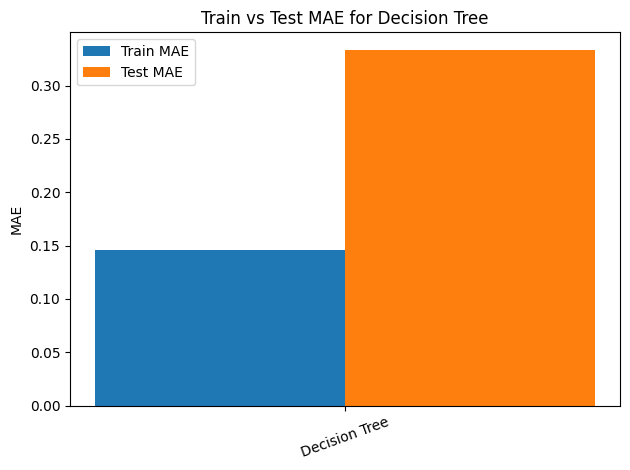

In [ ]:
# Visualize train vs test MAE for the Decision Tree model

models = ['Decision Tree']
train_mae = [mae_train]
test_mae = [mae]

x = range(len(models))
plt.bar(x, train_mae, width=0.4, label='Train MAE')
plt.bar([i + 0.4 for i in x], test_mae, width=0.4, label='Test MAE')

plt.xticks([i + 0.2 for i in x], models, rotation=20)
plt.ylabel('MAE')
plt.title('Train vs Test MAE for Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Visualization

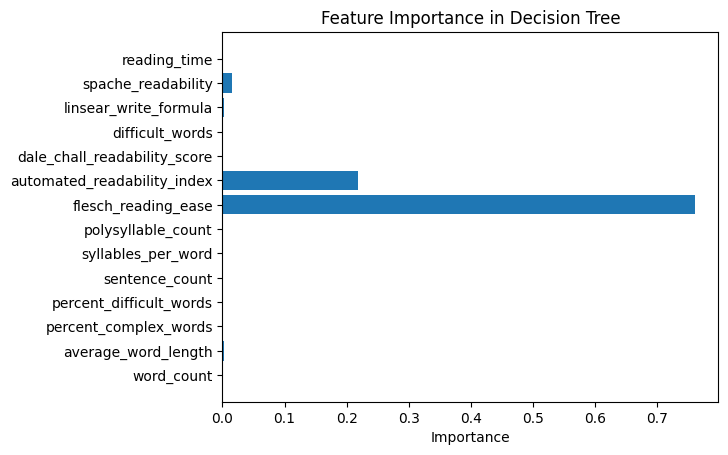

In [11]:
plt.barh(feature_columns, best_tree.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance in Decision Tree")
plt.show()

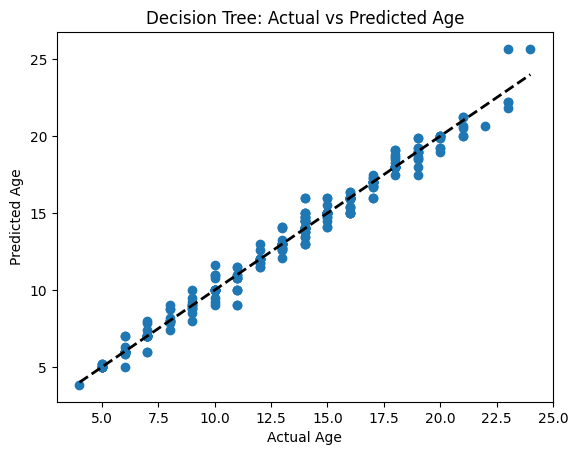

In [12]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Decision Tree: Actual vs Predicted Age")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

## Visualize the Decision Tree


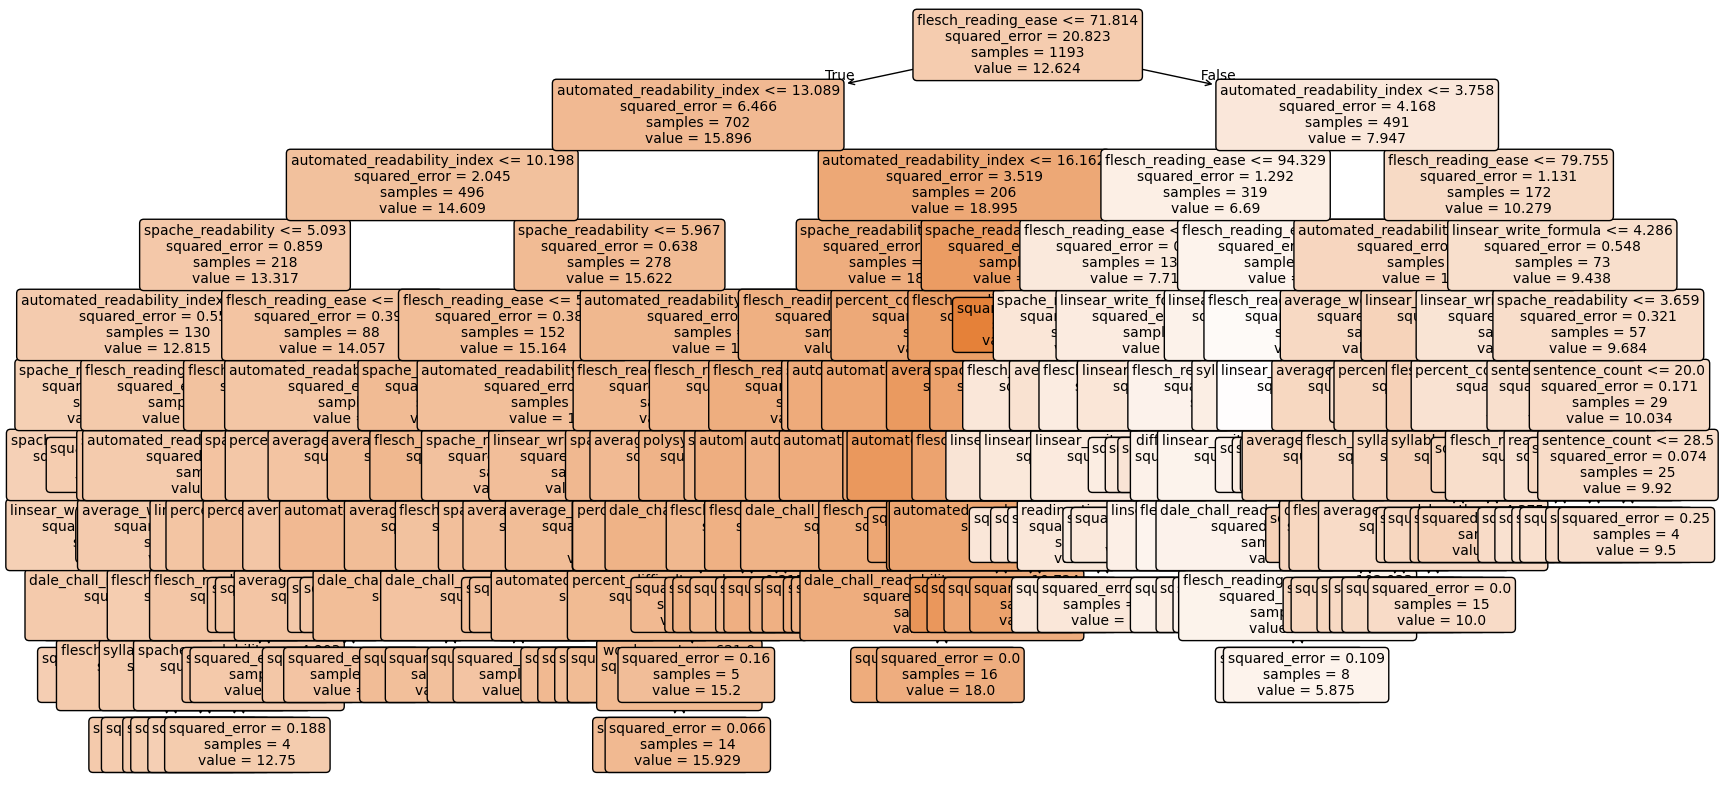

In [13]:
plt.figure(figsize=(20,10))
plot_tree(
    best_tree,
    feature_names=feature_columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()